# 10 — Facility-Level Downturn LGD

## Estimating the loss after default

PD is complete. This notebook estimates how much of EAD would be lost after recoveries and costs, with a separate downturn view for each facility.

Downturn LGD enters expected loss and the IRB unexpected-loss capital function. Lower collateral recovery, longer workouts and higher costs increase LGD and usually increase IRB RWA.

### Recovery and loss language

| Term | Simple meaning |
|---|---|
| Economic loss | EAD minus discounted recoveries plus material workout costs |
| Normal LGD | loss severity under ordinary recovery assumptions |
| Downturn LGD | loss severity reflecting periods of high credit losses where relevant |
| Workout cost | legal, servicing and recovery expense associated with default |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display as notebook_display
from pandas.io.formats.style import Styler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from basel_credit_risk.config import load_all_config

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)


def display(*objects, **kwargs):
    # Show complete table text and wrap long descriptions in saved notebook output.
    wrapped_objects = []
    for displayed_object in objects:
        if isinstance(displayed_object, pd.DataFrame):
            displayed_object = displayed_object.style
        if isinstance(displayed_object, Styler):
            displayed_object = displayed_object.set_properties(**{
                "white-space": "normal",
                "overflow-wrap": "anywhere",
                "text-align": "left",
                "vertical-align": "top",
                "max-width": "420px",
            }).set_table_styles([
                {"selector": "table", "props": [("width", "100%"), ("table-layout", "auto")]},
                {"selector": "th", "props": [
                    ("white-space", "normal"),
                    ("overflow-wrap", "anywhere"),
                    ("word-break", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("max-width", "180px"),
                ]},
            ], overwrite=False)
        wrapped_objects.append(displayed_object)
    return notebook_display(*wrapped_objects, **kwargs)

configs = load_all_config(ROOT / "config")
raw = pd.read_csv(ROOT / "data/generated/current_portfolio.csv.gz", low_memory=False)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)

print(f"Portfolio represented below: {len(loans):,} synthetic loan-level exposures")

Portfolio represented below: 30,000 synthetic loan-level exposures


> Recovery rates, recovery times and workout costs are synthetic. A bank would estimate LGD from discounted recoveries and costs on defaulted facilities, form a long-run default-weighted average and reflect periods of high loss severity.

## Recovery-to-LGD calculation

For each facility, collateral and unsecured recoveries are estimated, discounted over the recovery period and reduced for workout cost. Downturn assumptions lower recovery rates, increase costs and extend recovery time. Downturn LGD cannot fall below normal LGD in this implementation.

In [2]:
lgd_example = loans.loc[loans["collateral_value"].gt(0)].iloc[0]
display(pd.Series({
    "Product": lgd_example["product_type"],
    "EAD (INR crore)": lgd_example["ead_pre_crm"] / CRORE,
    "Collateral value (INR crore)": lgd_example["collateral_value"] / CRORE,
    "Normal discounted recovery (INR crore)": lgd_example["normal_discounted_recovery"] / CRORE,
    "Normal workout cost (INR crore)": lgd_example["normal_workout_cost"] / CRORE,
    "Normal LGD": lgd_example["normal_lgd"],
    "Downturn discounted recovery (INR crore)": lgd_example["downturn_discounted_recovery"] / CRORE,
    "Downturn workout cost (INR crore)": lgd_example["downturn_workout_cost"] / CRORE,
    "Downturn LGD": lgd_example["downturn_lgd"],
}).to_frame("Value"))

,Value
Product,mortgage
EAD (INR crore),0.209065
Collateral value (INR crore),0.287241
Normal discounted recovery (INR crore),0.186272
Normal workout cost (INR crore),0.006272
Normal LGD,0.139027
Downturn discounted recovery (INR crore),0.170616
Downturn workout cost (INR crore),0.012544
Downturn LGD,0.243911


The difference between normal and downturn LGD is not a universal fixed add-on. It comes from the facility's collateral, unsecured recovery, cost and timing assumptions. The values remain explicitly synthetic rather than being described as a bank-calibrated model.

## Normal and downturn LGD by product

The chart shows EAD-weighted average LGD. Secured products can have lower normal LGD, but downturn collateral and recovery assumptions narrow that benefit.

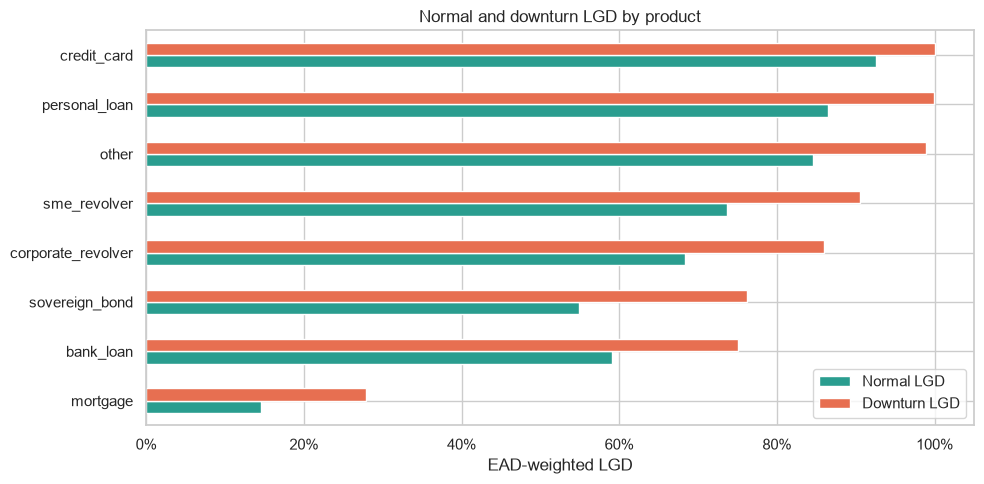

In [3]:
lgd_by_product = loans.groupby("product_type").apply(
    lambda group: pd.Series({
        "Normal LGD": np.average(group["normal_lgd"], weights=group["ead_irb"]),
        "Downturn LGD": np.average(group["downturn_lgd"], weights=group["ead_irb"]),
    }),
    include_groups=False,
).sort_values("Downturn LGD")
lgd_by_product.plot.barh(figsize=(10, 5), color=[COLORS[2], COLORS[5]], title="Normal and downturn LGD by product")
plt.xlabel("EAD-weighted LGD")
plt.ylabel("")
plt.gca().xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.tight_layout()
plt.show()

The gap between each pair of bars is the downturn effect. A higher downturn LGD means a larger share of EAD is assumed to remain unrecovered during difficult conditions and therefore increases both expected and unexpected loss measures.

Every facility has visible recovery rates, recovery time, workout cost, normal LGD and downturn LGD. Downturn LGD is carried into the IRB formula.